# Matlin Gilman | AC 209A Milestone 5

# 1. Problem Statement and Research Questions

Medicare’s **Hospital Value-Based Purchasing (VBP)** program adjusts hospital payments based on performance in four domains. Because the program is budget neutral, strong performance leads to bonuses, while weaker performance results in penalties.

The four domains hospitals can directly improve are:
- Clinical Outcomes
- Patient and Community Engagement (PCE)
- Safety
- Efficiency

#### Research Question
**Which of these four domains best predicts whether a hospital receives a bonus in a future year? And do these predictors differ between safety-net and non–safety-net hospitals?**

#### Note on Timing
In VBP, FY 2025 scores determine FY 2025 bonuses.  
Here, FY 2025 scores are used to predict FY 2026 bonuses.

#### Dataset
- FY 2026 bonus/penalty outcomes  
- FY 2025 scores for Clinical Outcomes, PCE, Safety, and Efficiency  
- Structural factors such as beds, region, and DSH percentages (used to identify safety-net hospitals)

#### Project Goal
To help hospitals—especially safety-net hospitals—understand **which performance domains matter most** for improving their chances of earning a future VBP bonus, and to guide targeted quality improvement efforts.


## Dataset preparation

In [1]:
# Import libraries for data handling, visualization, preprocessing, modeling, and evaluation

# =========================
# Core libraries
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

# =========================
# Modeling & preprocessing
# =========================
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# =========================
# Evaluation metrics
# =========================
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
)

# =========================
# Explainability
# =========================
import shap

In [2]:
# Load and clean FY2025 VBP domain scores, standardize fields, convert score data, and return sorted output.

vbp_scores_2025 = (
    pd.read_csv("vbp_scores_2025.csv")
      .rename(columns=lambda c: c.lower().replace(" ", "_"))
      .rename(columns={
          "facility_id": "hospital_id",
          "unweighted_normalized_clinical_outcomes_domain_score": "clinical_outcomes_score_2025",
          "unweighted_person_and_community_engagement_domain_score": "pce_score_2025",
          "unweighted_normalized_safety_domain_score": "safety_score_2025",
          "unweighted_normalized_efficiency_and_cost_reduction_domain_score": "efficiency_score_2025"
      })
)

score_cols = [
    "clinical_outcomes_score_2025",
    "pce_score_2025",
    "safety_score_2025",
    "efficiency_score_2025",
]

keep_cols = ["hospital_id"] + score_cols

vbp_scores_2025[score_cols] = (
    vbp_scores_2025[score_cols]
        .replace("Not Available", pd.NA)
        .apply(pd.to_numeric, errors="coerce")
)

vbp_scores_2025 = (
    vbp_scores_2025[keep_cols]
      .sort_values("hospital_id")
)

Loaded the FY2025 VBP domain scores, standardized column names, converted score fields to numeric, and produced a clean, hospital-sorted dataset for further analysis.

In [3]:
# Load and clean FY2026 VBP data, standardize hospital IDs, compute adjustment metrics, and produce final sorted output.

vbp_adj_2026 = (
    pd.read_excel("vbp_adj_2026.xlsx", skiprows=1)
      # Standardize column names
      .rename(columns=lambda c: c.strip().lower().replace(' ', '_'))
      # Rename variables
      .rename(columns={
          'cms_certification_number_(ccn)': 'hospital_id',
          'actual_fy_2026_hospital_vbp_adjustment_factor': 'vbp_adj_2026'
      })
)

vbp_adj_2026 = vbp_adj_2026[
    pd.to_numeric(vbp_adj_2026['hospital_id'], errors='coerce').notna()
].copy()

vbp_adj_2026['hospital_id'] = vbp_adj_2026['hospital_id'].astype(str).str.zfill(6)

vbp_adj_2026 = (
    vbp_adj_2026
      .assign(
          vbp_adj_pct_change_2026=lambda df: (df['vbp_adj_2026'] - 1) * 100,
          bonus_2026=lambda df: (df['vbp_adj_2026'] > 1.0).astype(int)
      )[["hospital_id", "vbp_adj_pct_change_2026", "bonus_2026"]]
      .sort_values("hospital_id")
)

Imported and standardized FY2026 VBP adjustment data, cleaned and normalized hospital IDs, computed adjustment-related metrics, and generated a final sorted dataset for analysis.

In [4]:
# Standardized hospital_id formatting and merge VBP adjustment and score datasets.

vbp_adj_2026["hospital_id"] = vbp_adj_2026["hospital_id"].astype(str).str.zfill(6)
vbp_scores_2025["hospital_id"] = vbp_scores_2025["hospital_id"].astype(str).str.zfill(6)

merged1 = vbp_adj_2026.merge(vbp_scores_2025, on="hospital_id", how="inner")

Standardized hospital IDs across datasets and merged FY2026 adjustment data with FY2025 score data to create a unified, analysis-ready table.

In [5]:
# Load FY2026 impact file, clean variables, and recode region/urbanicity

impact_file_2026 = (
    pd.read_excel("impact_file_2026.xlsx", sheet_name="FY 2026 FR", skiprows=1)
      .rename(columns=lambda c: (
          c.strip()
           .lower()
           .replace(" ", "_")
           .replace("-", "_")
      ))
)

# Keep needed columns
impact_file_2026 = (
    impact_file_2026
      .rename(columns={"provider_number": "hospital_id"})
      [["hospital_id", "dshpct", "region", "urgeo", "beds"]]
)

# ---- REGION RECODE ----
region_map = {
    1: 1, 2: 1,
    3: 2, 4: 2,
    5: 3, 6: 3,
    7: 4, 8: 4, 9: 4,
    40: 4
}

impact_file_2026["region"] = impact_file_2026["region"].map(region_map)

# ---- URBANICITY (replaces urgeo) ----
urbanicity_map = {"RURAL": 1, "LURBAN": 2, "OURBAN": 3}

impact_file_2026["urbanicity"] = (
    impact_file_2026["urgeo"]
      .astype(str)
      .str.strip()
      .str.upper()
      .map(urbanicity_map)
      .astype("Int64")
)

# Drop original urgeo
impact_file_2026 = impact_file_2026.drop(columns=["urgeo"])

Loaded and cleaned the FY2026 impact file to ensure consistent variable names, kept only fields needed for analysis, and recoded region and urbanicity so they align with simplified, analysis-ready categorical groupings used in downstream modeling.

In [6]:
# Format hospital_id and merge impact file data into the combined dataset.

impact_file_2026["hospital_id"] = impact_file_2026["hospital_id"].astype(str).str.zfill(6)

df = merged1.merge(impact_file_2026, on="hospital_id", how="inner")

Standardized hospital IDs for consistent merging and joined the cleaned impact file with the combined VBP dataset to create a unified table for downstream analysis.

In [7]:
# Create safety-net indicator based on hospitals in the top quartile of DSH percentage.

df["safety_net"] = (df["dshpct"] >= df["dshpct"].quantile(0.75)).astype(int)

Created a safety-net indicator by flagging hospitals in the top quartile of DSH percentage, enabling analyses comparing high-DSH hospitals to others.

# 2. EDA

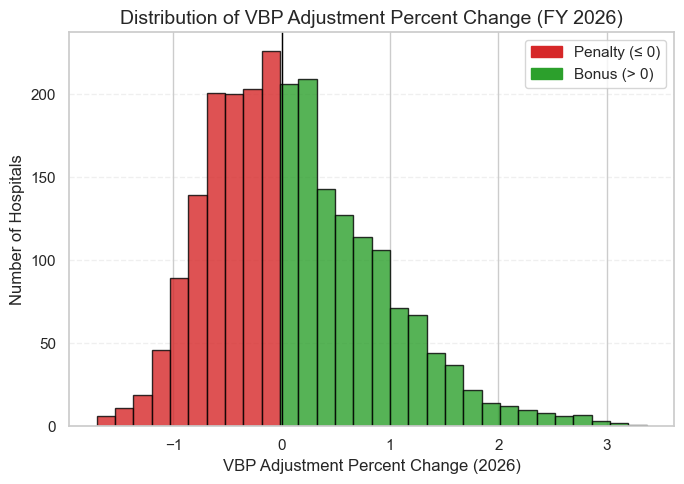

In [8]:
# Generate a color-coded histogram showing the distribution of VBP percent-change adjustments.

vals = df["vbp_adj_pct_change_2026"].dropna()

counts, bin_edges = np.histogram(vals, bins=30)

plt.figure(figsize=(7,5))

for count, left, right in zip(counts, bin_edges[:-1], bin_edges[1:]):
    
    color = "#d62728" if right <= 0 else "#2ca02c"
    
    plt.bar(
        left,
        count,
        width=right - left,
        align="edge",
        color=color,
        edgecolor="black",
        alpha=0.8
    )

plt.title("Distribution of VBP Adjustment Percent Change (FY 2026)", fontsize=14)
plt.xlabel("VBP Adjustment Percent Change (2026)")
plt.ylabel("Number of Hospitals")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.axvline(0, color="black", linewidth=1)

plt.legend(
    handles=[
        mpatches.Patch(color="#d62728", label="Penalty (≤ 0)"),
        mpatches.Patch(color="#2ca02c", label="Bonus (> 0)")
    ],
    fontsize=11
)

plt.tight_layout()
plt.show()

## Distribution of VBP Adjustment Percent Change (FY 2026)

#### What I Did
I created a histogram of hospitals’ **FY 2026 VBP payment adjustment percent changes**, coloring negative adjustments (penalties) in red and positive adjustments (bonuses) in green. This visualization displays the full distribution of financial outcomes under the VBP program.

#### Why I Did It
Before modeling, it is important to understand:
- how bonuses and penalties are distributed,
- whether the outcome is balanced,
- and whether the financial adjustments cluster around certain values.

This helps determine whether a binary bonus/penalty classification is appropriate and whether more complex modeling of the continuous percent change might be needed.

#### What I Found
- The distribution is roughly centered around **0%**, with penalties on the left and bonuses on the right.
- There are **slightly more bonus hospitals than penalty hospitals**, but the difference is small enough that class imbalance is not a concern.
- Most adjustments fall between **–1% and +2%**, indicating that financial impacts are meaningful but not extreme.
- The smooth overlap of red and green bars suggests a continuous relationship between performance and payment, supporting the use of both classification and predictive modeling approaches.

This initial visualization provides a clear picture of VBP financial outcomes and sets the stage for modeling bonus status and understanding its predictors.

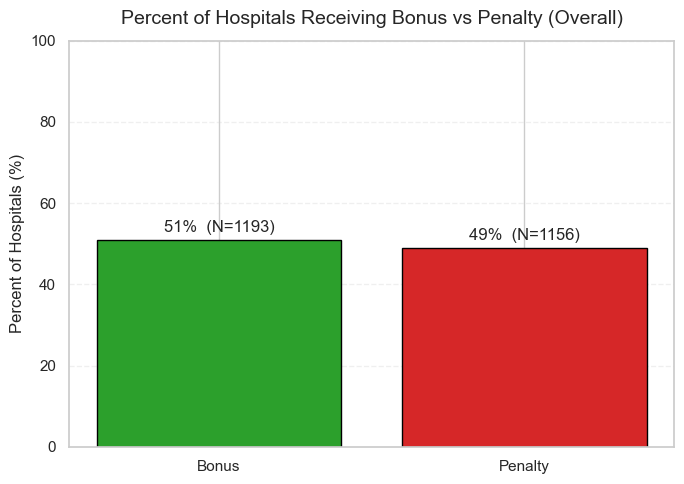

In [9]:
# Calculate bonus/penalty distribution and plot hospital percentages with counts.

bonus_n = (df["bonus_2026"] == 1).sum()
penalty_n = (df["bonus_2026"] == 0).sum()

total = bonus_n + penalty_n
bonus_pct = round(bonus_n / total * 100)
penalty_pct = round(penalty_n / total * 100)

categories = ["Bonus", "Penalty"]
values = [bonus_pct, penalty_pct]
counts = [bonus_n, penalty_n]

plt.figure(figsize=(7,5))

bars = plt.bar(
    categories,
    values,
    color=["#2ca02c", "#d62728"],
    edgecolor="black"
)

plt.title("Percent of Hospitals Receiving Bonus vs Penalty (Overall)", fontsize=14, pad=12)
plt.ylabel("Percent of Hospitals (%)", fontsize=12)
plt.ylim(0, 100)

# Add labels
for bar, pct, n in zip(bars, values, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{pct}%  (N={n})",
        ha="center",
        fontsize=12
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Inspecting the Outcome Variable: `bonus_2026`

Before building a logistic regression model, it is essential to understand the distribution of the outcome variable—in this case, whether a hospital receives a **bonus** or a **penalty** in 2026 (`bonus_2026`). Logistic regression assumes a binary outcome but does *not* require perfectly balanced classes. However, class imbalance can affect model performance, choice of metrics, and whether resampling or class-weight adjustments are needed.

To assess this, I calculated the **frequency** and **percentage** of hospitals receiving a bonus (`bonus_2026 = 1`) versus a penalty (`bonus_2026 = 0`). I then visualized these proportions with a simple bar chart to understand the balance between the two groups.

### What I Found

The results show:

- **51%** of hospitals received a **bonus** (N = 1,193)  
- **49%** received a **penalty** (N = 1,156)

This distribution is **almost perfectly balanced**, which is ideal for logistic regression. Because neither class dominates, we likely do **not** need special techniques such as oversampling, undersampling, or class-weighted loss functions. It also means that **accuracy**, along with other metrics (AUC, precision, recall), will be reasonable to interpret.

This initial inspection confirms that the outcome variable is well-behaved and appropriate for baseline logistic regression modeling without additional class-imbalance adjustments.


=== clinical_outcomes_score_2025 ===
N = 2313
Mean = 17.04, Std = 15.75
Min = 0.00, 25% = 5.00, Median = 14.00, 75% = 25.00, Max = 96.67
Skewness = 1.33


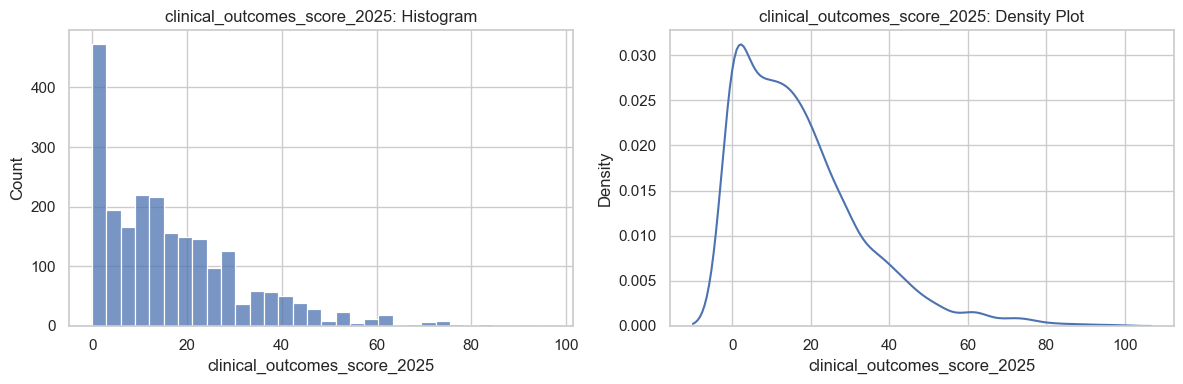


=== pce_score_2025 ===
N = 2346
Mean = 20.48, Std = 15.27
Min = 0.00, 25% = 10.00, Median = 16.00, 75% = 26.75, Max = 100.00
Skewness = 1.65


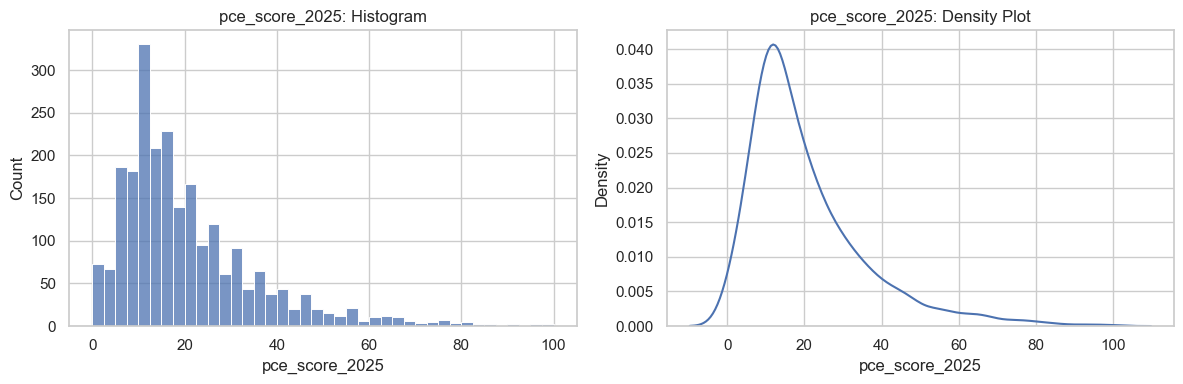


=== safety_score_2025 ===
N = 1977
Mean = 39.58, Std = 22.35
Min = 0.00, 25% = 22.00, Median = 36.00, 75% = 52.00, Max = 100.00
Skewness = 0.58


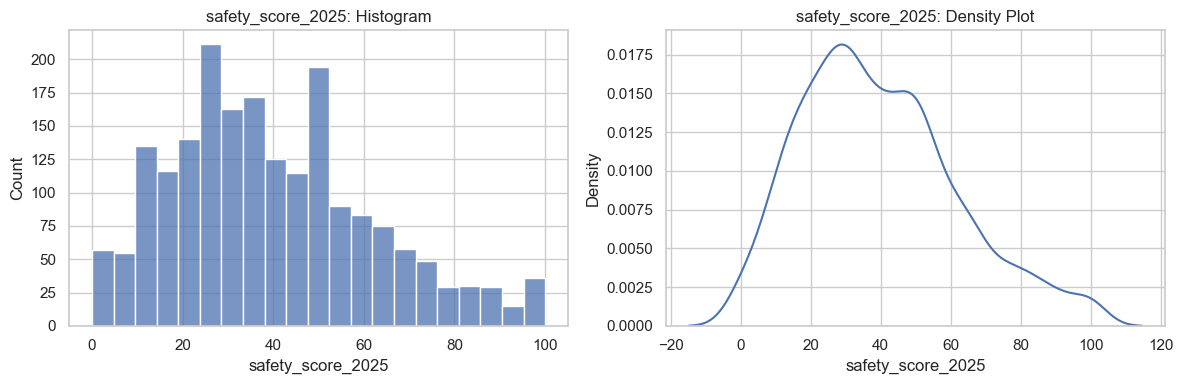


=== efficiency_score_2025 ===
N = 2349
Mean = 19.88, Std = 25.50
Min = 0.00, 25% = 0.00, Median = 10.00, 75% = 30.00, Max = 100.00
Skewness = 1.41


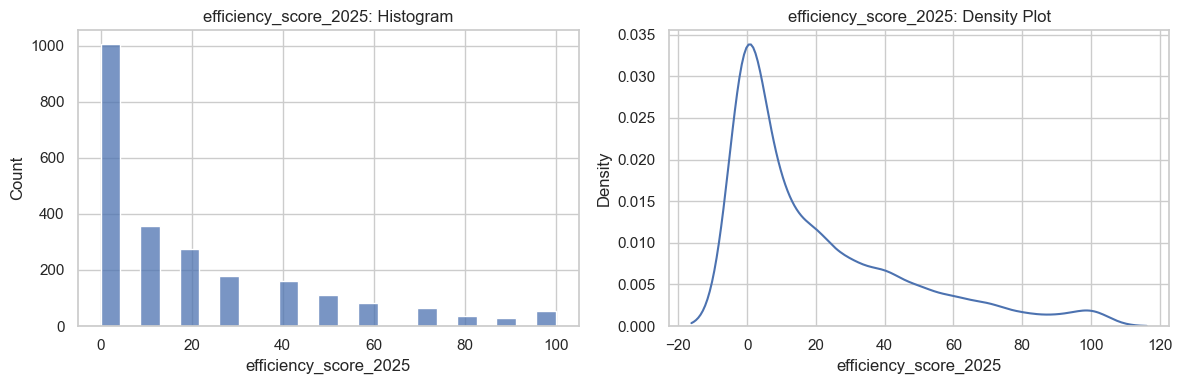


=== dshpct ===
N = 2349
Mean = 0.31, Std = 0.15
Min = 0.01, 25% = 0.21, Median = 0.29, 75% = 0.36, Max = 1.06
Skewness = 1.36


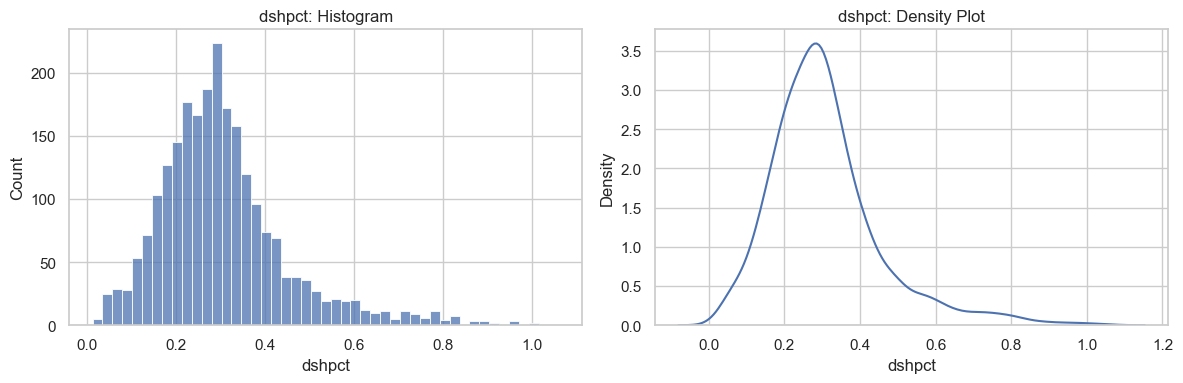


=== beds ===
N = 2349
Mean = 233.28, Std = 225.80
Min = 15.00, 25% = 89.00, Median = 169.00, 75% = 303.00, Max = 2850.00
Skewness = 3.19


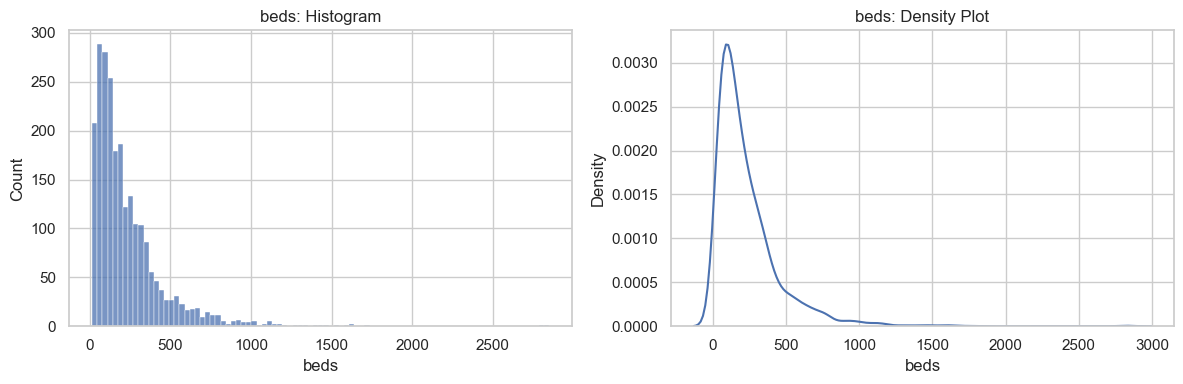


=== region ===
        Count  Percent
region                
4         794     33.8
3         626     26.6
2         547     23.3
1         382     16.3


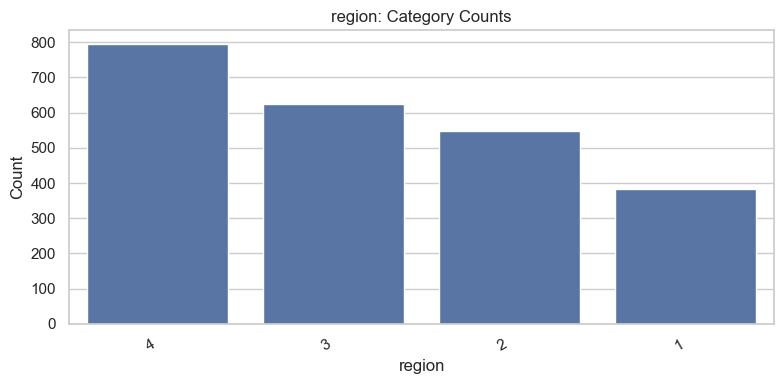


=== urbanicity ===
            Count  Percent
urbanicity                
3             984     41.9
2             867     36.9
1             498     21.2


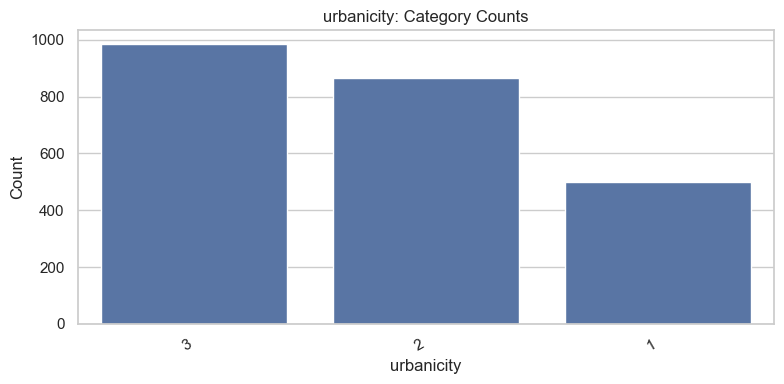

In [10]:
# -------------------------
# 1. Set up
# -------------------------

continuous_vars = [
    "clinical_outcomes_score_2025",
    "pce_score_2025",
    "safety_score_2025",
    "efficiency_score_2025",
    "dshpct",
    "beds",
]

categorical_vars = [
    "region",
    "urbanicity",
]

# -------------------------
# 2. Continuous Variables
# -------------------------
for col in continuous_vars:
    if col not in df.columns:
        print(f"Warning: {col} not in dataframe, skipping.")
        continue

    data = df[col].dropna()

    print(f"\n=== {col} ===")
    print(f"N = {data.shape[0]}")
    print(f"Mean = {data.mean():.2f}, Std = {data.std():.2f}")
    print(f"Min = {data.min():.2f}, 25% = {data.quantile(0.25):.2f}, "
          f"Median = {data.median():.2f}, 75% = {data.quantile(0.75):.2f}, "
          f"Max = {data.max():.2f}")
    print(f"Skewness = {data.skew():.2f}")

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(data, kde=False, ax=ax[0])
    ax[0].set_title(f"{col}: Histogram")
    ax[0].set_xlabel(col)
    ax[0].set_ylabel("Count")

    # Density plot
    sns.kdeplot(data, ax=ax[1])
    ax[1].set_title(f"{col}: Density Plot")
    ax[1].set_xlabel(col)
    ax[1].set_ylabel("Density")

    plt.tight_layout()
    plt.show()

# -------------------------
# 3. Categorical Variables
# -------------------------
for col in categorical_vars:
    if col not in df.columns:
        print(f"Warning: {col} not in dataframe, skipping.")
        continue

    counts = df[col].value_counts(dropna=False)
    perc = df[col].value_counts(normalize=True, dropna=False) * 100

    print(f"\n=== {col} ===")
    summary = pd.DataFrame({"Count": counts, "Percent": perc.round(1)})
    print(summary)

    # Flag very low-frequency categories (e.g., < 5% of sample)
    low_freq = summary[summary["Percent"] < 5]
    if not low_freq.empty:
        print("\n  Low-frequency categories (<5% of hospitals):")
        print(low_freq)

    # Bar plot of category counts
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=counts.index)
    plt.title(f"{col}: Category Counts")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


## Univariate Exploration of Predictors

Here, I examined each predictor’s distribution to identify skew, outliers, and category balance, and to determine simple preprocessing steps that would improve the baseline logistic regression model.

#### What I Did
- Plotted histograms and density curves for all continuous predictors and reviewed skewness.  
- Checked level counts for `region` and `urbanicity` to ensure adequate representation.

#### What I Found
- Continuous predictors were right-skewed (`beds, efficiency, PCE, clinical outcomes, safety, DSH`), with `beds` showing the strongest skew and very large maximum values.  
- Categorical variables were well distributed across levels, so no merging or recoding was needed.

#### What This Means for the Baseline Model
To strengthen the baseline logistic regression model:

1. Log-transform the skewed continuous predictors (`beds, efficiency, PCE, clinical outcomes, safety, DSH`). This reduces the influence of extreme values and helps create more linear relationships with the log-odds. Even when skew is moderate rather than severe, log-transforming does not typically harm the model and often improves stability.

2. Standardize all continuous predictors. This puts them on comparable scales, improves numerical stability, and makes coefficient interpretation more straightforward.

3. Keep categorical variables unchanged, since their distributions are appropriate for modeling.

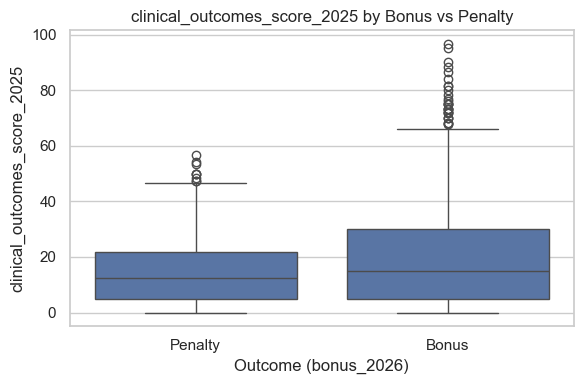

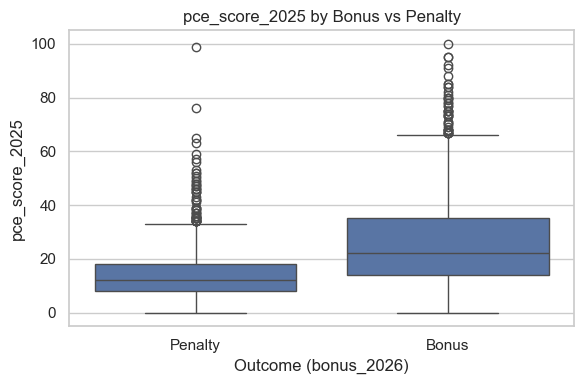

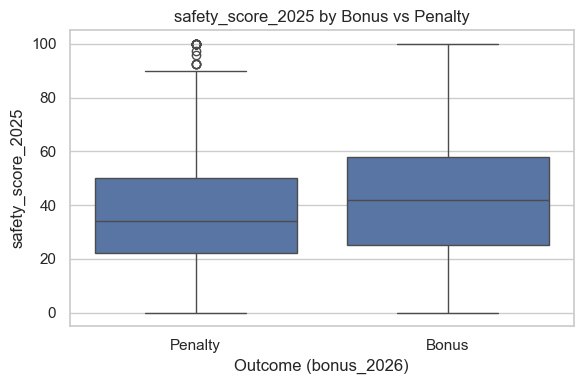

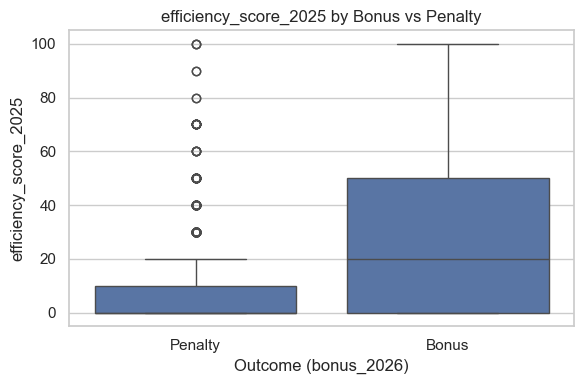

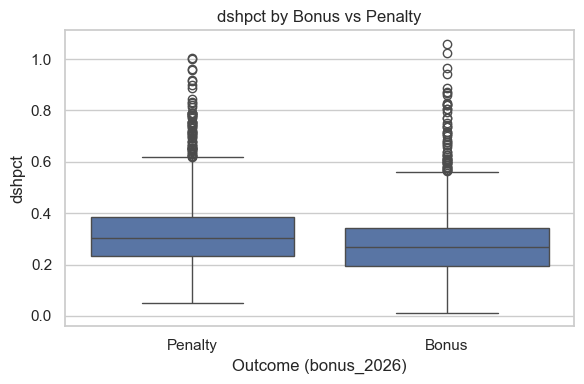

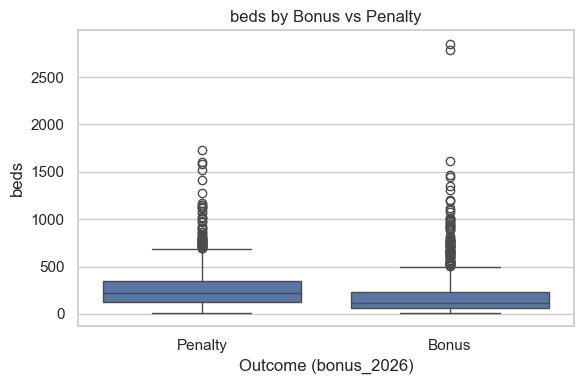


=== region: Bonus Rates by Category ===


,region,bonus_rate,n
0,2,55.393053,547
1,4,52.518892,794
2,1,47.905759,382
3,3,46.325879,626


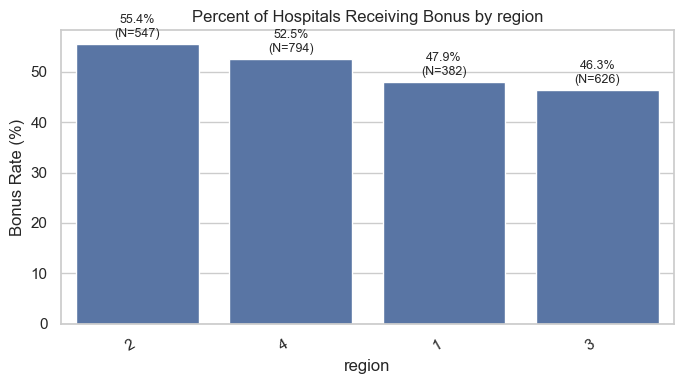


=== urbanicity: Bonus Rates by Category ===


,urbanicity,bonus_rate,n
0,1,66.265060,498
1,2,49.596309,867
2,3,44.004065,984


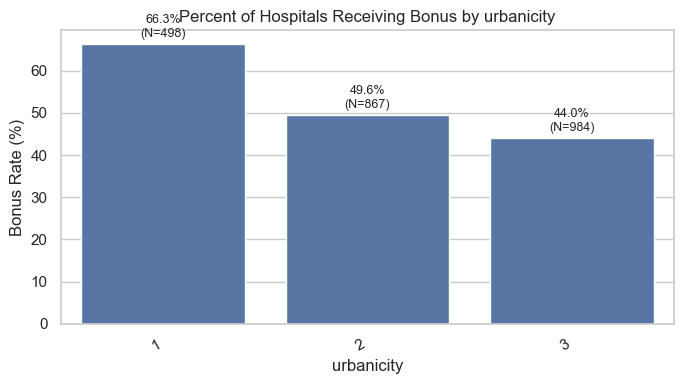

In [11]:
# -------------------------------------------------------------------
# Setup: define predictors and create a readable outcome label
# -------------------------------------------------------------------
continuous_vars = [
    "clinical_outcomes_score_2025",
    "pce_score_2025",
    "safety_score_2025",
    "efficiency_score_2025",
    "dshpct",
    "beds",
]

categorical_vars = [
    "region",
    "urbanicity",
]

# Optional: create a label for plotting
df["bonus_label"] = np.where(df["bonus_2026"] == 1, "Bonus", "Penalty")

# -------------------------------------------------------------------
# 1) Continuous predictors vs. binary outcome (boxplots)
# -------------------------------------------------------------------
for col in continuous_vars:
    if col not in df.columns:
        print(f"Warning: {col} not in dataframe, skipping.")
        continue
    
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        data=df,
        x="bonus_label",
        y=col,
        order=["Penalty", "Bonus"]
    )
    plt.title(f"{col} by Bonus vs Penalty")
    plt.xlabel("Outcome (bonus_2026)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------------
# 2) Categorical predictors vs. outcome (bonus rate by category)
# -------------------------------------------------------------------
for col in categorical_vars:
    if col not in df.columns:
        print(f"Warning: {col} not in dataframe, skipping.")
        continue

    # Calculate bonus rate by category (assuming 1 = bonus)
    rate = df.groupby(col)["bonus_2026"].mean().sort_values(ascending=False)
    counts = df[col].value_counts().reindex(rate.index)

    bonus_rate_df = pd.DataFrame({
        col: rate.index,
        "bonus_rate": (rate.values * 100),   # percent
        "n": counts.values
    })

    print(f"\n=== {col}: Bonus Rates by Category ===")
    display(bonus_rate_df)

    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=bonus_rate_df,
        x=col,
        y="bonus_rate",
        order=bonus_rate_df[col],
    )
    plt.title(f"Percent of Hospitals Receiving Bonus by {col}")
    plt.ylabel("Bonus Rate (%)")
    plt.xlabel(col)
    plt.xticks(rotation=30, ha="right")

    # Add labels on top of bars
    ax = plt.gca()
    for p, rate_val, n_val in zip(ax.patches, bonus_rate_df["bonus_rate"], bonus_rate_df["n"]):
        ax.annotate(
            f"{rate_val:.1f}%\n(N={n_val})",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )

    plt.tight_layout()
    plt.show()


## Bivariate Relationships With the Outcome

Here, I examined how each predictor relates to the binary outcome (`bonus_2026`) to understand which variables show meaningful differences between bonus and penalty hospitals, and to identify where transformations or nonlinear modeling may be helpful.

#### What I Did
- Created boxplots for all continuous predictors, comparing their distributions between hospitals receiving a bonus and those receiving a penalty.
- Calculated and plotted bonus rates across categories for `region` and `urbanicity`.

#### What I Found
- Continuous predictors generally showed **higher scores among bonus hospitals**, with the clearest separation in:
  - `clinical_outcomes_score_2025`
  - `pce_score_2025`
  - `safety_score_2025`
  - `efficiency_score_2025` (largest visual separation)
- Differences in `dshpct` and `beds` were modest, though variability was high.
- Urbanicity showed a strong pattern: **rural hospitals had the highest bonus rates**, while large urban systems had the lowest.
- Regional variation existed as well, though less pronounced than urbanicity.

#### What This Means for the Baseline Model
- Several predictors have **clear monotonic relationships** with the outcome even before transformation, indicating they will likely be strong contributors in the logistic regression model.
- Some predictors (especially `efficiency_score_2025` and `beds`) show large variability and skew, reinforcing the need for the log transformations planned earlier.
- The categorical predictors (`region`, `urbanicity`) meaningfully differ in bonus rates and should be retained as independent predictors in the baseline model.
- These patterns support moving forward with the improved baseline model using:
  - log-transformed skewed continuous predictors,
  - standardized continuous predictors, and
  - unchanged categorical predictors.

This bivariate assessment confirms that many predictors are informative and that the preprocessing steps identified earlier will help capture their relationships with the outcome more effectively.

Correlation Matrix:


,clinical_outcomes_score_2025,pce_score_2025,safety_score_2025,efficiency_score_2025,dshpct,beds
clinical_outcomes_score_2025,1.000000,0.023015,-0.128936,-0.047678,-0.026934,0.385946
pce_score_2025,0.023015,1.000000,0.053404,0.163099,-0.251920,-0.130486
safety_score_2025,-0.128936,0.053404,1.000000,0.049619,-0.051169,-0.299283
efficiency_score_2025,-0.047678,0.163099,0.049619,1.000000,-0.076321,-0.232069
dshpct,-0.026934,-0.251920,-0.051169,-0.076321,1.000000,0.176124
beds,0.385946,-0.130486,-0.299283,-0.232069,0.176124,1.000000


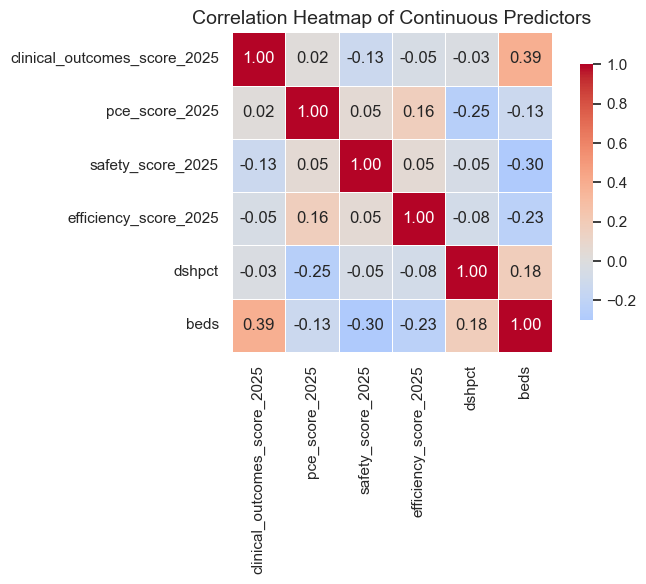

In [12]:
# ---------------------------------------------------------
# 1. Select continuous predictors
# ---------------------------------------------------------
continuous_vars = [
    "clinical_outcomes_score_2025",
    "pce_score_2025",
    "safety_score_2025",
    "efficiency_score_2025",
    "dshpct",
    "beds"
]

# Drop missing rows only for correlation computation
df_cont = df[continuous_vars].dropna()

# ---------------------------------------------------------
# 2. Compute correlation matrix
# ---------------------------------------------------------
corr_matrix = df_cont.corr()

print("Correlation Matrix:")
display(corr_matrix)

# ---------------------------------------------------------
# 3. Plot heatmap
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Continuous Predictors", fontsize=14)
plt.tight_layout()
plt.show()


## Check Multicollinearity

Here, I examined correlations among the continuous predictors to determine whether any variables are redundant or highly related, which could create instability in the logistic regression model.

#### What I Did
- Computed a correlation matrix using all continuous predictors.  
- Visualized the relationships using a heatmap to identify pairs with moderate or high correlation.

#### What I Found
- Correlations across predictors were generally low.  
- The highest correlation observed was between `beds` and `clinical_outcomes_score_2025` (r ≈ 0.39), which is still well below levels that raise multicollinearity concerns (commonly r > 0.7).  
- Most other correlations were close to zero and showed no concerning patterns.

#### What This Means for the Baseline Model
- No continuous predictors appear redundant or strongly collinear.  
- All predictors can remain in the model without causing multicollinearity issues.  
- This supports keeping the full set of predictors in the baseline logistic regression model.

In [13]:
# ----------------------------------------------------------
# 1. Summaries of missing data per variable
# ----------------------------------------------------------

cols_for_missing = [c for c in df.columns if c not in ["hospital_id"]]

missing_counts = df[cols_for_missing].isna().sum()
missing_pct = df[cols_for_missing].isna().mean() * 100

missing_summary = (
    pd.DataFrame({
        "missing_n": missing_counts,
        "missing_pct": missing_pct.round(1)
    })
    .sort_values("missing_pct", ascending=False)
)

print("Missingness summary (sorted by % missing):")
display(missing_summary)

# ----------------------------------------------------------
# 2. Check whether missingness is related to the outcome
# ----------------------------------------------------------

if "bonus_2026" in df.columns:
    outcome = "bonus_2026"
    results = []

    for col in cols_for_missing:
        if col == outcome:
            continue

        miss_flag = df[col].isna().astype(int)

        # Skip if no missing values for this variable
        if miss_flag.sum() == 0:
            continue

        bonus_rate_present = df.loc[miss_flag == 0, outcome].mean() * 100
        bonus_rate_missing = df.loc[miss_flag == 1, outcome].mean() * 100

        results.append({
            "variable": col,
            "n_missing": int(miss_flag.sum()),
            "bonus_rate_present": round(bonus_rate_present, 1),
            "bonus_rate_missing": round(bonus_rate_missing, 1)
        })

    if results:
        print("\nBonus rates for records with vs. without missing values:")
        display(pd.DataFrame(results))
    else:
        print("\nNo predictors have missing values.")
else:
    print("Outcome 'bonus_2026' not found — skipping missingness vs. outcome check.")


Missingness summary (sorted by % missing):


,missing_n,missing_pct
safety_score_2025,372,15.8
clinical_outcomes_score_2025,36,1.5
pce_score_2025,3,0.1
vbp_adj_pct_change_2026,0,0.0
bonus_2026,0,0.0
efficiency_score_2025,0,0.0
dshpct,0,0.0
region,0,0.0
beds,0,0.0
urbanicity,0,0.0



Bonus rates for records with vs. without missing values:


,variable,n_missing,bonus_rate_present,bonus_rate_missing
0,clinical_outcomes_score_2025,36,50.4,77.8
1,pce_score_2025,3,50.9,0.0
2,safety_score_2025,372,45.6,78.5


## Missing Data Assessment and Handling

#### What I Did
- Checked how much data was missing for each predictor.  
- Found missing values only in three VBP domains: **Safety**, **Clinical Outcomes**, and **PCE**.  
- Compared bonus rates for hospitals with vs. without missing scores to see whether missingness carried information.

#### What I Found
- Safety had the most missingness (15.8%); the other domains had very little.  
- Hospitals with missing scores often had **higher bonus rates**, meaning missingness is not random but tied to program rules (e.g., low volume, CMS suppression).  
- No hospital characteristics were missing.

#### Why Domain Scores Are Missing in VBP
In the VBP program, when a domain score is missing, **it is simply excluded from the hospital’s adjustment calculation**—CMS redistributes weights across the remaining domains.  
Missing scores therefore **do not hurt or help** a hospital’s payment adjustment.

#### Why Mean Imputation + Missing Indicators Makes Sense
Because missing domains do not factor into VBP adjustments, **mean imputation effectively mirrors CMS’s treatment**: the missing domain contributes a neutral value, while the **missingness indicator** captures the fact that the hospital was low-volume or exempt.

This approach keeps the analysis focused on the real question:

> **Which VBP domains matter most for predicting future bonus outcomes?**

By neutralizing the missing domain (as CMS does), the model concentrates on the domains that actually influence payment adjustments.


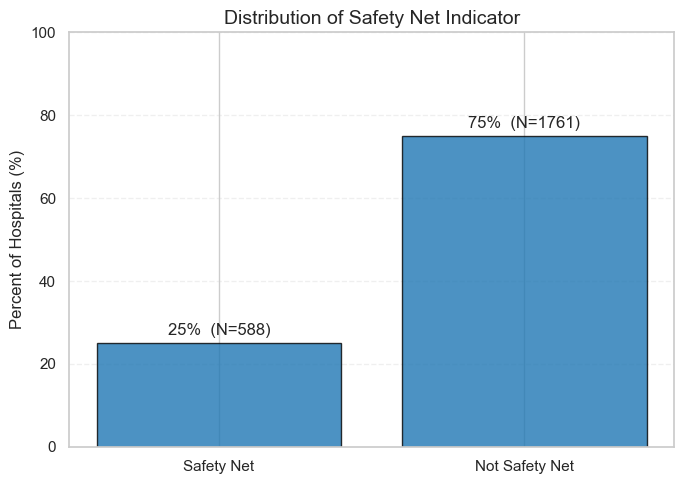

In [14]:
# Plot the percentage distribution of safety-net vs non–safety-net hospitals with counts.

vals = df["safety_net"].dropna()

order = [1, 0]

counts = vals.value_counts().reindex(order)
counts.index = ["Safety Net", "Not Safety Net"]

total = counts.sum()
pcts = (counts / total * 100).round().astype(int)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    counts.index,
    pcts,
    color="#1f77b4",
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution of Safety Net Indicator", fontsize=14)
plt.ylabel("Percent of Hospitals (%)", fontsize=12)
plt.ylim(0, 100)

# Add labels on each bar: "XX%  (N=###)"
for bar, pct, n in zip(bars, pcts, counts):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{pct}%  (N={n})",
        ha="center",
        fontsize=12
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Distribution of Safety-Net Hospitals

Safety-net hospitals make up **25%** of the sample (N=588), while **75%** are non–safety-net hospitals (N=1761).  
This imbalance is important to keep in mind when comparing outcomes or modeling differences between the two groups.

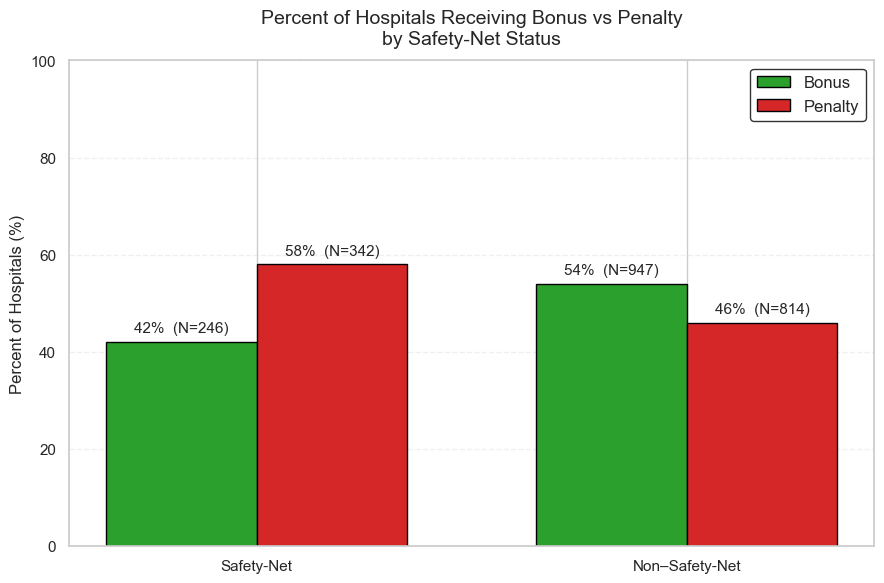

In [15]:
# Compare bonus vs penalty rates between safety-net and non–safety-net hospitals using grouped bar charts.

group = df.groupby("safety_net")

bonus_counts = group["bonus_2026"].sum()
total_counts = group["bonus_2026"].count()
penalty_counts = total_counts - bonus_counts

bonus_pct = (bonus_counts / total_counts * 100).round(0)
penalty_pct = (penalty_counts / total_counts * 100).round(0)

rename_map = {0: "Non–Safety-Net", 1: "Safety-Net"}
bonus_pct = bonus_pct.rename(index=rename_map)
penalty_pct = penalty_pct.rename(index=rename_map)
bonus_counts = bonus_counts.rename(index=rename_map)
penalty_counts = penalty_counts.rename(index=rename_map)

categories = ["Safety-Net", "Non–Safety-Net"]

bonus_pct = bonus_pct.reindex(categories)
penalty_pct = penalty_pct.reindex(categories)
bonus_counts = bonus_counts.reindex(categories)
penalty_counts = penalty_counts.reindex(categories)

x = np.arange(len(categories))
bar_width = 0.35

plt.figure(figsize=(9, 6))

bars_bonus = plt.bar(
    x - bar_width / 2,
    bonus_pct.values,
    width=bar_width,
    color="#2ca02c",
    edgecolor="black",
    label="Bonus"
)

bars_penalty = plt.bar(
    x + bar_width / 2,
    penalty_pct.values,
    width=bar_width,
    color="#d62728",
    edgecolor="black",
    label="Penalty"
)

plt.title(
    "Percent of Hospitals Receiving Bonus vs Penalty\nby Safety-Net Status",
    fontsize=14,
    pad=12
)
plt.ylabel("Percent of Hospitals (%)", fontsize=12)
plt.xticks(x, categories)
plt.ylim(0, 100)

for bar, pct, n in zip(bars_bonus, bonus_pct.values, bonus_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        pct + 2,
        f"{int(pct)}%  (N={int(n)})",
        ha="center",
        fontsize=11
    )

for bar, pct, n in zip(bars_penalty, penalty_pct.values, penalty_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        pct + 2,
        f"{int(pct)}%  (N={int(n)})",
        ha="center",
        fontsize=11
    )

plt.legend(fontsize=12, frameon=True, edgecolor="black")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Bonus Rates by Safety-Net Status

#### What I Did
Here, I compared the share of hospitals receiving bonuses versus penalties for **safety-net** and **non–safety-net** hospitals to assess baseline differences between the two groups.

#### What I Found
- **Safety-net hospitals** were more likely to receive a **penalty** (58%) than a bonus (42%).  
- **Non–safety-net hospitals** showed the opposite pattern, with **54%** receiving a bonus and **46%** receiving a penalty.

#### Interpretation
Safety-net hospitals start from a disadvantaged position in the VBP program: even before modeling, they receive bonuses at substantially lower rates than other hospitals. This highlights the importance of examining whether the predictors of bonus status differ across these groups and whether certain domains disproportionately affect safety-net performance.


In [16]:
# 1. Copy data and set up outcome

# Work on a copy so original df stays intact
df_model = df.copy()

# Outcome vector
y = df_model["bonus_2026"].astype(int)

# 2. Mean impute and create missingness indicators

# Variables with missingness
vars_with_missing = [
    "safety_score_2025",
    "clinical_outcomes_score_2025",
    "pce_score_2025"
]

for col in vars_with_missing:
    # Missingness indicator (1 = missing, 0 = observed)
    df_model[f"miss_{col}"] = df_model[col].isna().astype(int)
    
    # Mean imputation
    df_model[col] = df_model[col].fillna(df_model[col].mean())

# 3. Log-transform skewed continuous predictors

# Raw continuous predictors
cont_raw = [
    "clinical_outcomes_score_2025",
    "pce_score_2025",
    "safety_score_2025",
    "efficiency_score_2025",
    "dshpct",
    "beds"
]

# Beds has no zeros, so use log; others use log1p to be safe with zeros
df_model["log_beds"] = np.log(df_model["beds"])

df_model["log_clinical_outcomes_score_2025"] = np.log1p(df_model["clinical_outcomes_score_2025"])
df_model["log_pce_score_2025"] = np.log1p(df_model["pce_score_2025"])
df_model["log_safety_score_2025"] = np.log1p(df_model["safety_score_2025"])
df_model["log_efficiency_score_2025"] = np.log1p(df_model["efficiency_score_2025"])
df_model["log_dshpct"] = np.log1p(df_model["dshpct"])

# These are the continuous predictors you plan to actually use in the model
cont_transformed = [
    "log_clinical_outcomes_score_2025",
    "log_pce_score_2025",
    "log_safety_score_2025",
    "log_efficiency_score_2025",
    "log_dshpct",
    "log_beds"
]

# 4. Standardize continuous predictors

scaler = StandardScaler()

cont_transformed_z = [c + "_z" for c in cont_transformed]

df_model[cont_transformed_z] = scaler.fit_transform(df_model[cont_transformed])

# 5. One-hot encode categorical predictors

cat_vars = ["region", "urbanicity"]

df_model = pd.get_dummies(df_model, columns=cat_vars, drop_first=True)

# Collect dummy column names
cat_dummy_cols = [
    c for c in df_model.columns
    if c.startswith("region_") or c.startswith("urbanicity_")
]

# 6. Assemble final feature matrix X and check shapes

# Missingness indicators for all three variables with missing data
miss_cols = [f"miss_{c}" for c in vars_with_missing]

# Final set of predictors:
#   - standardized log-transformed continuous variables
#   - missingness indicators
#   - categorical dummies
X_cols = cont_transformed_z + miss_cols + cat_dummy_cols

X = df_model[X_cols]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (2349, 14)
y shape: (2349,)


,log_clinical_outcomes_score_2025_z,log_pce_score_2025_z,log_safety_score_2025_z,log_efficiency_score_2025_z,log_dshpct_z,log_beds_z,miss_safety_score_2025,miss_clinical_outcomes_score_2025,miss_pce_score_2025,region_2,region_3,region_4,urbanicity_2,urbanicity_3
0,1.092103,-0.155025,-0.126180,-1.100903,-0.176636,0.873984,0,0,0,False,True,False,False,True
1,0.628848,-0.155025,-0.667796,-1.100903,0.121893,0.132353,0,0,0,False,True,False,False,False
2,-1.097842,-0.840872,1.340486,-1.100903,-0.716034,0.367950,0,0,0,False,True,False,False,True
3,0.286306,1.227367,0.566148,-1.100903,-0.132566,-0.597402,0,0,0,False,True,False,False,False
4,0.727098,-0.454623,-0.961657,-1.100903,-1.201700,0.309290,0,0,0,False,True,False,True,False


## Preparing the Data for the Baseline Model

I prepared the predictors for logistic regression by addressing missing data, skewed distributions, scale differences, and categorical coding. These steps ensure the model is stable, interpretable, and aligned with how VBP data behave.

#### What I Did
- Created **missingness indicators** and **mean-imputed** the three domains with missing values so that all hospitals remain in the analysis.
- **Log-transformed** skewed continuous predictors (beds, domain scores, DSH pct) and then **standardized** them to place all predictors on comparable scales.
- **One-hot encoded** categorical variables (region, urbanicity).
- Built the final feature matrix using standardized continuous predictors, missingness indicators, and dummies.
- Included **DSHPCT** (percentage of low-income patients) rather than the safety-net indicator itself; the safety-net variable is reserved for comparisons later.
- Included structural variables (beds, region, DSHPCT) to control for underlying hospital differences and avoid confounding the estimated effects of the VBP domains.

#### Why I Did It
- Missingness indicators + mean imputation reflect how CMS treats missing values (neutral contribution) while capturing patterns associated with low-volume hospitals.
- Log transformation and standardization improve model fit and coefficient interpretability.
- Structural variables help ensure that domain effects are estimated net of major hospital-level differences.
- Overall, these preprocessing steps create a clean and consistent dataset for assessing which VBP domains best predict future bonus status.


# 3. Baseline Model

Train shape: (1644, 14) (1644,)
Test shape: (705, 14) (705,)
Model fitted.
Accuracy: 0.736
ROC AUC: 0.822

Confusion Matrix (rows = true, cols = predicted):
[[264  83]
 [103 255]]

Classification Report:
              precision    recall  f1-score   support

           0      0.719     0.761     0.739       347
           1      0.754     0.712     0.733       358

    accuracy                          0.736       705
   macro avg      0.737     0.737     0.736       705
weighted avg      0.737     0.736     0.736       705



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linea

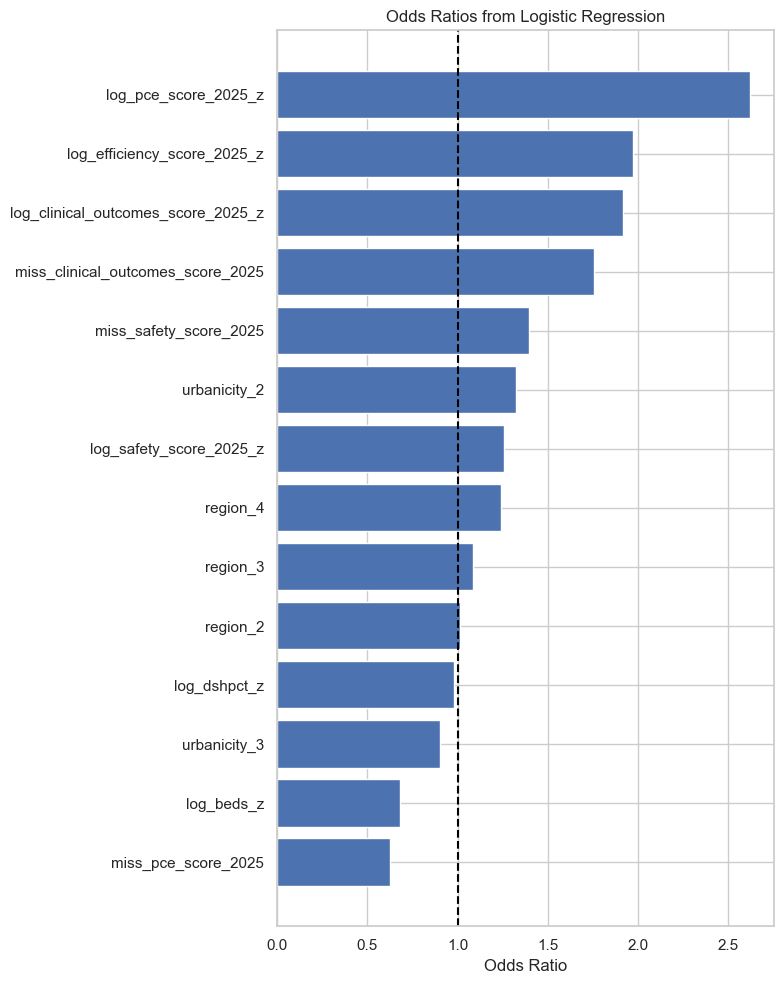

In [17]:
# 1. Splitting the Data

# Train–test split (stratified to preserve bonus/penalty balance)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,      # 30% test, 70% train (adjust if you prefer)
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

# 2. Fitting the Baseline Logistic Regression Model

from sklearn.linear_model import LogisticRegression

# Baseline logistic regression
# L2 penalty is standard; with scaled predictors this is a reasonable default
log_reg = LogisticRegression(
    penalty="l2",
    C=1.0,          # regularization strength (1.0 is a typical baseline)
    solver="lbfgs",
    max_iter=1000
)

log_reg.fit(X_train, y_train)

print("Model fitted.")

# 3. Evaluating Predictive Performance

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]  # probability of bonus = 1

# Core metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.3f}")
print(f"ROC AUC: {auc:.3f}")
print("\nConfusion Matrix (rows = true, cols = predicted):")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

# 4. Examining Odds Ratios

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build coef + OR DataFrame
coef = log_reg.coef_[0]
coef_df = pd.DataFrame({
    "feature": X.columns,
    "odds_ratio": np.exp(coef)
})

# Sort by OR for readability
coef_df = coef_df.sort_values("odds_ratio")

# Simple plot
plt.figure(figsize=(8, 10))
plt.barh(coef_df["feature"], coef_df["odds_ratio"])
plt.axvline(1.0, color="black", linestyle="--")  # OR = 1 reference line
plt.xlabel("Odds Ratio")
plt.title("Odds Ratios from Logistic Regression")
plt.tight_layout()
plt.show()


## Baseline Logistic Regression Model

I fit a baseline logistic regression model to assess how well the prepared predictors explain bonus status (`bonus_2026`) and to establish a transparent reference point before moving to a more flexible modeling approach.

#### What I Did
- Split the data into **training (70%)** and **testing (30%)** sets using stratification.
- Fit a **logistic regression model** with L2 regularization (`C = 1.0`) using standardized, log-transformed predictors, missingness indicators, and categorical dummies.
- Evaluated performance using accuracy, ROC AUC, a confusion matrix, and precision–recall metrics.
- Converted coefficients to **odds ratios** and plotted them to visualize each predictor’s influence.

#### What I Found
- The model performed well for a baseline:  
  - **Accuracy:** ~0.74  
  - **AUC:** ~0.82  
- Odds ratios revealed clear predictor patterns:  
  - Domain scores (PCE, efficiency, clinical outcomes) were the strongest positive contributors.  
  - Missingness indicators carried meaningful and independent signal.  
  - Larger hospitals (beds) had lower odds of receiving a bonus.  
  - Region and urbanicity had smaller but interpretable effects.

#### What This Means for Modeling Choices
- Logistic regression provides an interpretable starting point and confirms that key VBP domain scores meaningfully predict future bonuses.
- However, the results also suggest that **some predictors do not relate to bonus status in a strictly linear way**, even after log transformation and standardization.  
  - Boxplots showed uneven separation across predictor ranges.  
  - Missingness indicators were highly predictive, indicating threshold or structural effects.  
  - Domain scores showed varying effect sizes that may interact with one another or operate non-linearly.

These patterns indicate that a linear model may not fully capture the complexity of the relationships in the VBP data. This motivates fitting a **random forest model**, which can naturally learn non-linear relationships and interactions and provide a more complete picture of which VBP domain features are most important for predicting bonus outcomes.

# 4. Random Forest and SHAP

X_raw shape: (2349, 14)
RF Train shape: (1644, 14) (1644,)
RF Test shape: (705, 14) (705,)
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best cross-validated AUC (RF, raw features): 0.8420030883712217
Best hyperparameters:
  min_samples_split: 10
  min_samples_leaf: 2
  min_impurity_decrease: 0.001
  max_features: 0.5
  max_depth: 7

Random Forest (Raw Features) - Test Accuracy: 0.773
Random Forest (Raw Features) - Test ROC AUC: 0.846
Random Forest (Raw Features) - Test F1: 0.764

Random Forest - Confusion Matrix (rows = true, cols = predicted):
[[286  61]
 [ 99 259]]

Random Forest - Classification Report:
              precision    recall  f1-score   support

           0      0.743     0.824     0.781       347
           1      0.809     0.723     0.764       358

    accuracy                          0.773       705
   macro avg      0.776     0.774     0.773       705
weighted avg      0.777     0.773     0.773       705


=== Model Comparison on Test Set ===
Logi

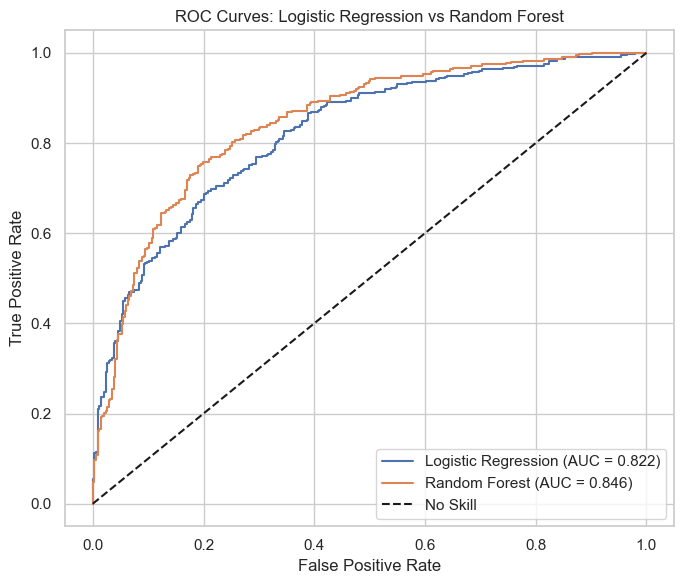

In [18]:
# --------------------------------------------------
# 1. Build raw feature matrix for Random Forest
# --------------------------------------------------

# Raw continuous predictors (not transformed or standardized)
cont_raw = [
    "clinical_outcomes_score_2025",
    "pce_score_2025",
    "safety_score_2025",
    "efficiency_score_2025",
    "dshpct",
    "beds"
]

# Missingness indicators (created earlier)
vars_with_missing = [
    "safety_score_2025",
    "clinical_outcomes_score_2025",
    "pce_score_2025"
]
miss_cols = [f"miss_{c}" for c in vars_with_missing]

# Region / urbanicity dummies (already in df_model)
cat_dummy_cols = [
    c for c in df_model.columns
    if c.startswith("region_") or c.startswith("urbanicity_")
]

# Assemble raw-feature matrix for RF
X_raw_cols = cont_raw + miss_cols + cat_dummy_cols
X_raw = df_model[X_raw_cols]

print("X_raw shape:", X_raw.shape)

# --------------------------------------------------
# 2. Split Data for Random Forest
#    (Logistic regression has already been run on
#    transformed X with its own train/test split.)
# --------------------------------------------------

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_raw,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("RF Train shape:", X_train_rf.shape, y_train_rf.shape)
print("RF Test shape:", X_test_rf.shape, y_test_rf.shape)

# --------------------------------------------------
# 3. Define the Random Forest Model
# --------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=500,   # fixed number of trees
    random_state=42,
    n_jobs=-1
)

# --------------------------------------------------
# 4. Create the Hyperparameter Search Space
# --------------------------------------------------

param_dist = {
    "max_depth": [None, 3, 5, 7, 9, 12],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.3, 0.5, None],
    "min_impurity_decrease": [0.0, 1e-4, 1e-3, 1e-2],
}

# --------------------------------------------------
# 5. Set up RandomizedSearchCV
# --------------------------------------------------

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,              # number of random combos to try
    scoring="roc_auc",      # optimize for AUC
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# --------------------------------------------------
# 6. Fit the Search Process
# --------------------------------------------------

rf_search.fit(X_train_rf, y_train_rf)

print("Best cross-validated AUC (RF, raw features):", rf_search.best_score_)
print("Best hyperparameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")

# Best tuned random forest model
rf_best = rf_search.best_estimator_

# --------------------------------------------------
# 7. Evaluate the Tuned RF Model on the Test Set
# --------------------------------------------------

y_pred_rf = rf_best.predict(X_test_rf)
y_proba_rf = rf_best.predict_proba(X_test_rf)[:, 1]

acc_rf = accuracy_score(y_test_rf, y_pred_rf)
auc_rf = roc_auc_score(y_test_rf, y_proba_rf)
f1_rf = f1_score(y_test_rf, y_pred_rf)   # F1 for bonus class (1)
cm_rf = confusion_matrix(y_test_rf, y_pred_rf)

print("\nRandom Forest (Raw Features) - Test Accuracy:", round(acc_rf, 3))
print("Random Forest (Raw Features) - Test ROC AUC:", round(auc_rf, 3))
print("Random Forest (Raw Features) - Test F1:", round(f1_rf, 3))
print("\nRandom Forest - Confusion Matrix (rows = true, cols = predicted):")
print(cm_rf)
print("\nRandom Forest - Classification Report:")
print(classification_report(y_test_rf, y_pred_rf, digits=3))

# --------------------------------------------------
# 8. Compare Tuned RF vs. Logistic Regression
#    Logistic regression metrics (acc, auc, y_pred,
#    y_proba, y_test) come from your earlier cell
#    where you fit log_reg on transformed X.
# --------------------------------------------------

f1_log = f1_score(y_test, y_pred)   # F1 for bonus class (1)

print("\n=== Model Comparison on Test Set ===")
print(f"Logistic Regression (transformed features) - Accuracy: {acc:.3f}, AUC: {auc:.3f}, F1: {f1_log:.3f}")
print(f"Random Forest (raw features)              - Accuracy: {acc_rf:.3f}, AUC: {auc_rf:.3f}, F1: {f1_rf:.3f}")

# --------------------------------------------------
# 9. ROC Curves for Logistic Regression vs. Random Forest
# --------------------------------------------------

# ROC for logistic regression (transformed features)
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba)

# ROC for random forest (raw features)
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, y_proba_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="No Skill")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Logistic Regression vs Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Random Forest Model and Performance Comparison

To evaluate whether a more flexible model could better capture relationships in the VBP data, I trained and tuned a random forest model using **raw predictors**—the original VBP domain scores, beds, DSH percent, missingness indicators, and one-hot–encoded region and urbanicity. These predictors are appropriately formatted for tree-based models, which accept numeric inputs, handle skew and scale differences naturally, and do not require transformations or standardization.

#### What I Did
- Constructed a raw predictor dataset (`X_raw`) including domain scores, structural characteristics, and missingness indicators.
- Tuned a random forest using **RandomizedSearchCV** (5-fold CV, optimizing AUC) across a search space that varied:
  - **max_depth** (`None`, 3, 5, 7, 9, 12)  
  - **min_samples_split** (2, 5, 10, 20)  
  - **min_samples_leaf** (1, 2, 4, 8)  
  - **max_features** (`"sqrt"`, `"log2"`, 0.3, 0.5, `None`)  
  - **min_impurity_decrease** (0, 1e-4, 1e-3, 1e-2)  
- Evaluated the tuned model on a held-out test set using **accuracy**, **AUC**, and **F1 score**.
- Compared performance against the baseline logistic regression model trained on transformed predictors.
- Plotted **ROC curves** for both models to visualize discrimination between bonus and penalty hospitals.

#### What I Found
- **Random Forest (raw predictors):** Accuracy **0.773**, AUC **0.846**, F1 **0.764**  
- **Logistic Regression (transformed predictors):** Accuracy **0.736**, AUC **0.822**, F1 **0.733**  
- The random forest consistently outperformed logistic regression, and its ROC curve remained above the logistic regression curve across nearly all thresholds.

#### Interpretation
- The random forest captures **nonlinearities** and **interactions** among domain scores and hospital characteristics, leading to stronger predictive performance.
- Logistic regression provides an interpretable baseline but is limited by its linear structure even after transformations and standardization.
- Including structural variables (beds, region, DSH percent) and missingness indicators ensures domain effects are estimated while controlling for real differences in hospital context and CMS reporting rules.
- The ROC curves confirm that the random forest separates bonus and penalty hospitals more effectively across the full probability range.

Overall, the random forest provides a more accurate and flexible model for identifying which VBP domains best predict future bonus outcomes, while logistic regression remains useful for interpretability and benchmarking.


In [19]:
# 1. Prepare the data used for SHAP (must match RF training features)

# These were defined when you trained the random forest:
cont_raw = [
    "clinical_outcomes_score_2025",
    "pce_score_2025",
    "safety_score_2025",
    "efficiency_score_2025",
    "dshpct",
    "beds"
]
vars_with_missing = [
    "safety_score_2025",
    "clinical_outcomes_score_2025",
    "pce_score_2025"
]
miss_cols = [f"miss_{c}" for c in vars_with_missing]
cat_dummy_cols = [
    c for c in df_model.columns
    if c.startswith("region_") or c.startswith("urbanicity_")
]

X_raw_cols = cont_raw + miss_cols + cat_dummy_cols

# Use the same data structure as RF (you can use full data or just test set)
X_shap = df_model[X_raw_cols]          # or X_test_rf if you prefer
y_shap = df_model["bonus_2026"]        # reference only

print("X_shap shape:", X_shap.shape)

# 2. SHAP TreeExplainer and SHAP values for rf_best

import shap
shap.initjs()

explainer = shap.TreeExplainer(rf_best)

# Explanation object
shap_exp = explainer(X_shap, check_additivity=False)
print("shap_exp shape:", shap_exp.shape)

# Extract raw values
vals = shap_exp.values

# For tree models, SHAP often returns (n_samples, n_features, n_classes)
# Focus on class 1 (bonus) if needed
if vals.ndim == 3:
    vals_bonus = vals[:, :, 1]
else:
    vals_bonus = vals

print("vals_bonus shape:", vals_bonus.shape)


X_shap shape: (2349, 14)


shap_exp shape: (2349, 14, 2)
vals_bonus shape: (2349, 14)


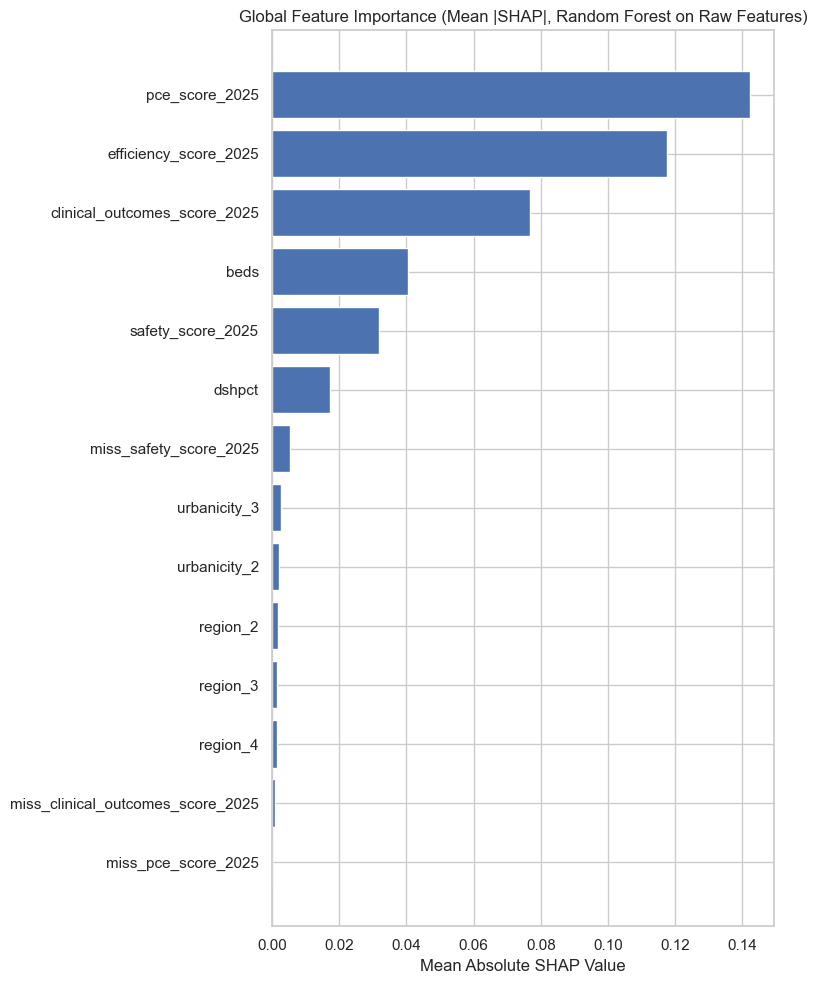

In [20]:
global_importance = np.abs(vals_bonus).mean(axis=0)
gi_df = pd.DataFrame({
    "feature": X_shap.columns,
    "importance": global_importance
}).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 10))
plt.barh(gi_df["feature"], gi_df["importance"])
plt.title("Global Feature Importance (Mean |SHAP|, Random Forest on Raw Features)")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.show()



## Global SHAP Feature Importance (Random Forest on Raw Predictors)

After fitting the tuned random forest model, I used SHAP values to identify which predictors had the greatest overall influence on hospitals’ predicted likelihood of receiving a VBP bonus. **SHAP (SHapley Additive exPlanations)** is a unified framework for interpreting machine learning models. It assigns each feature a contribution value for every prediction, based on principles from cooperative game theory.  

I chose SHAP because:
- it works well with **complex, nonlinear models** like random forests,  
- it provides **consistent, mathematically grounded measures of feature importance**,  
- it allows for both **global explanations** (which features matter most overall) and **local explanations** (why a specific hospital received its predicted probability),  
- and it produces results that are easier to interpret than traditional feature importance measures from tree models.

#### What I Did
- Computed SHAP values for every hospital using the raw predictors fed into the random forest.
- Calculated the **mean absolute SHAP value** for each predictor, representing its average contribution—positive or negative—to bonus predictions.
- Ranked predictors by their mean |SHAP| values to identify which variables the model relied on most.

#### What I Found
- All four **VBP performance domains**—**PCE**, **Efficiency**, **Clinical Outcomes**, and **Safety**—were among the most influential predictors.
- **PCE** was the strongest overall driver of bonus predictions, followed by **Efficiency** and **Clinical Outcomes**.
- **Safety** contributed positively but to a lesser extent.
- Structural characteristics (**beds**, **region**, **urbanicity**, **DSH percent**) and missingness indicators played much smaller roles.

#### Interpretation
The random forest depends primarily on **domain performance—factors hospitals can directly improve**—rather than on structural characteristics outside their control. This aligns with the logistic regression results, which also highlighted PCE, Efficiency, and Clinical Outcomes as the strongest positive predictors, with Safety playing a smaller but meaningful role.

While the random forest allows for nonlinearities and interactions, the **overall ranking of the domains** matches the simpler baseline model. This strengthens confidence that these domains—particularly **PCE and Efficiency**—are central to predicting whether a hospital receives a VBP bonus.


Selected hospital row index: 11
Hospital ID: 010036


Predicted probability of bonus for hospital 010036: 0.59
Actual VBP outcome (2026): Bonus


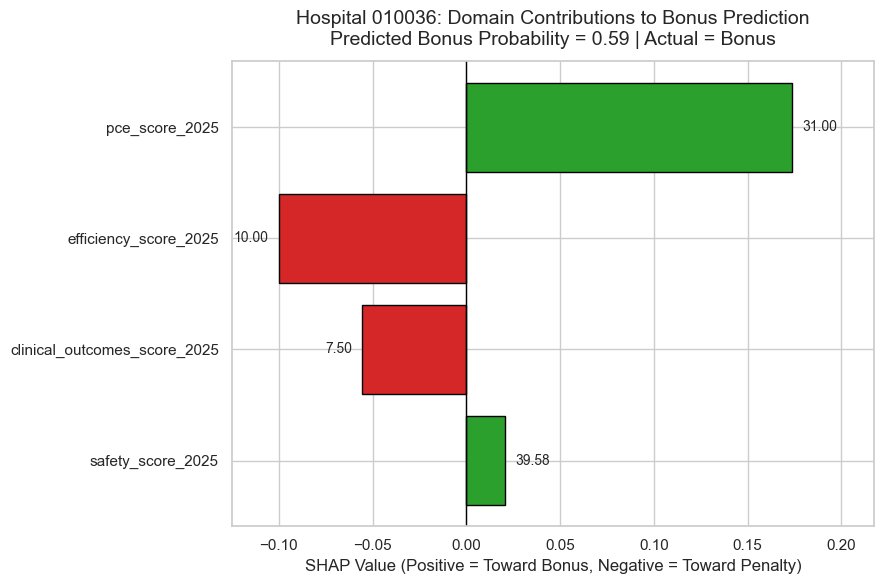

In [21]:
# Generate a SHAP explanation plot for an individual hospital’s bonus prediction,
# showing ONLY the controllable domain predictors and with labels that don't
# overlap the plot edges.

hospital_id = "010036"  # <-- change as needed

# 1. Find the hospital row index
matches = df.index[df["hospital_id"] == hospital_id]

if len(matches) == 0:
    raise ValueError(f"Hospital ID {hospital_id} not found in df['hospital_id'].")

i = matches[0]

print("Selected hospital row index:", i)
print("Hospital ID:", df.loc[i, "hospital_id"])


# 2. Reconstruct the RF feature matrix (raw features used for training)

cont_raw = [
    "clinical_outcomes_score_2025",
    "pce_score_2025",
    "safety_score_2025",
    "efficiency_score_2025",
    "dshpct",
    "beds"
]

vars_with_missing = [
    "safety_score_2025",
    "clinical_outcomes_score_2025",
    "pce_score_2025"
]
miss_cols = [f"miss_{c}" for c in vars_with_missing]

cat_dummy_cols = [
    c for c in df_model.columns
    if c.startswith("region_") or c.startswith("urbanicity_")
]

X_raw_cols = cont_raw + miss_cols + cat_dummy_cols
X_shap = df_model[X_raw_cols]


# 3. Compute SHAP values for the RF model

import shap
shap.initjs()

explainer = shap.TreeExplainer(rf_best)
shap_exp = explainer(X_shap, check_additivity=False)

vals = shap_exp.values

# If SHAP returns (samples, features, classes), select class 1 = bonus
if vals.ndim == 3:
    vals_bonus = vals[:, :, 1]
else:
    vals_bonus = vals


# 4. Extract SHAP values AND feature values ONLY for controllable predictors

controllable_features = [
    "clinical_outcomes_score_2025",
    "pce_score_2025",
    "safety_score_2025",
    "efficiency_score_2025"
]

df_scores_i = pd.DataFrame({
    "feature": controllable_features,
    "shap_value": [vals_bonus[i, X_raw_cols.index(f)] for f in controllable_features],
    "feature_value": [X_shap.loc[i, f] for f in controllable_features]
})

df_scores_i["abs"] = df_scores_i["shap_value"].abs()
df_scores_i = df_scores_i.sort_values("abs", ascending=False)


# 5. Predicted bonus probability & actual outcome

prob_raw = rf_best.predict_proba(X_shap.iloc[[i]])[0, 1]
prob_display = f"{prob_raw:.2f}"

actual_label = df.loc[i, "bonus_2026"]
actual_outcome = "Bonus" if actual_label == 1 else "Penalty"

print(f"Predicted probability of bonus for hospital {hospital_id}: {prob_display}")
print(f"Actual VBP outcome (2026): {actual_outcome}")


# 6. SHAP bar plot (ONLY controllable domain scores, with non-overlapping labels)

import matplotlib.pyplot as plt
import numpy as np

colors = df_scores_i["shap_value"].apply(
    lambda v: "#2ca02c" if v > 0 else "#d62728"
)

plt.figure(figsize=(9, 6))
plt.barh(
    df_scores_i["feature"],
    df_scores_i["shap_value"],
    color=colors,
    edgecolor="black"
)
plt.axvline(0, color="black", linewidth=1)

plt.title(
    f"Hospital {hospital_id}: Domain Contributions to Bonus Prediction\n"
    f"Predicted Bonus Probability = {prob_display} | Actual = {actual_outcome}",
    fontsize=14,
    pad=12
)
plt.xlabel(
    "SHAP Value (Positive = Toward Bonus, Negative = Toward Penalty)",
    fontsize=12
)

# Determine x-limits and add padding so labels don't overlap the plot edges
x_min = df_scores_i["shap_value"].min()
x_max = df_scores_i["shap_value"].max()

# If all values are very close, avoid zero-width range
if x_max == x_min:
    x_min -= 0.1
    x_max += 0.1

plt.xlim(x_min * 1.25, x_max * 1.25)

# Label each bar with the actual feature value, offset away from the bar end
offset = 0.02 * (x_max - x_min)

for y, (shap_v, fv) in enumerate(zip(df_scores_i["shap_value"], df_scores_i["feature_value"])):
    label = f"{fv:.2f}" if isinstance(fv, (float, np.floating)) else str(fv)
    plt.text(
        shap_v + (offset if shap_v >= 0 else -offset),
        y,
        label,
        va="center",
        ha="left" if shap_v >= 0 else "right",
        fontsize=10
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Local SHAP Explanation for an Individual Hospital

To understand how the random forest makes predictions for a specific hospital, I generated a local SHAP plot for Hospital **010036**, focusing only on the four performance domains that hospitals can directly influence.

#### What I Did
- Computed SHAP values for Hospital 010036 using the tuned random forest.
- Extracted contributions only for: **PCE**, **Efficiency**, **Clinical Outcomes**, and **Safety**.
- Plotted each domain’s SHAP value to show how it pushed the prediction toward either *bonus* (positive) or *penalty* (negative).

#### What I Found
- The model predicted a **0.59 probability of receiving a bonus**, which matches the hospital’s actual outcome.
- **PCE score** was the strongest positive driver of the bonus prediction.
- **Safety score** also pushed the prediction upward.
- **Efficiency** and **Clinical Outcomes** scores contributed negatively, reducing the hospital’s predicted probability.

#### Interpretation
Despite weaker Efficiency and Clinical Outcomes scores, strong PCE and Safety performance ultimately shifted the prediction above 0.50. This shows how the model weighs different VBP domains and highlights which areas may be most influential or actionable for improving bonus likelihood at the individual hospital level.


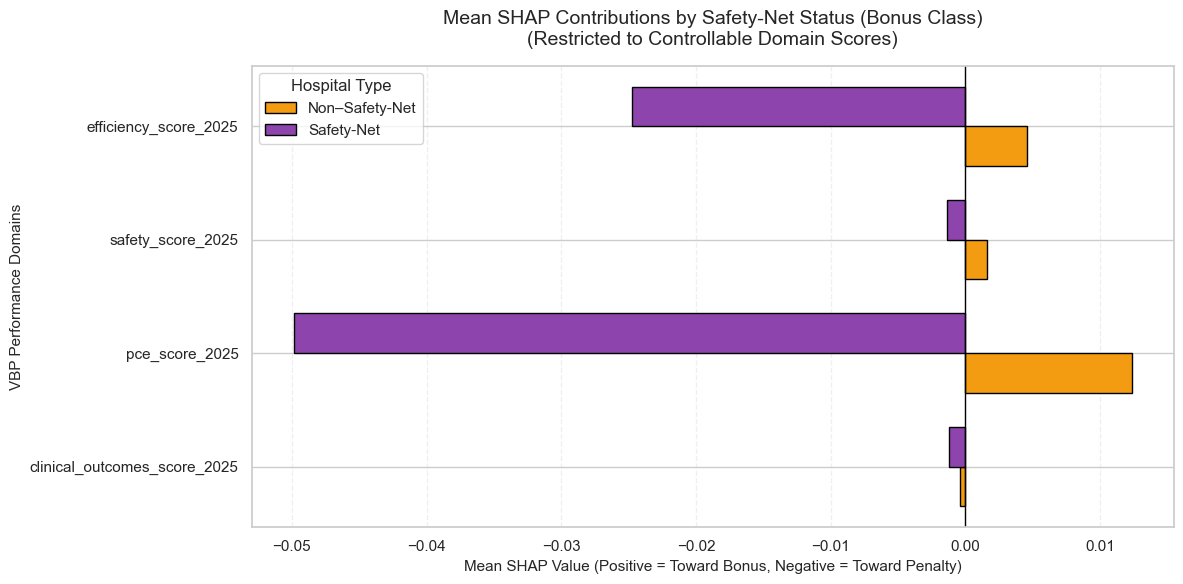

In [22]:
# Compare mean SHAP feature contributions between safety-net and non–safety-net hospitals
# for the four controllable domains.

# 1. Make sure we have SHAP values for the RF on X_shap (same as before)

cont_raw = [
    "clinical_outcomes_score_2025",
    "pce_score_2025",
    "safety_score_2025",
    "efficiency_score_2025",
    "dshpct",
    "beds"
]
vars_with_missing = [
    "safety_score_2025",
    "clinical_outcomes_score_2025",
    "pce_score_2025"
]
miss_cols = [f"miss_{c}" for c in vars_with_missing]
cat_dummy_cols = [
    c for c in df_model.columns
    if c.startswith("region_") or c.startswith("urbanicity_")
]

X_raw_cols = cont_raw + miss_cols + cat_dummy_cols
X_shap = df_model[X_raw_cols]

import shap
explainer = shap.TreeExplainer(rf_best)
shap_exp = explainer(X_shap, check_additivity=False)

vals = shap_exp.values
# Focus on bonus class (1) if 3D
if vals.ndim == 3:
    vals_bonus = vals[:, :, 1]
else:
    vals_bonus = vals

# 2. Build a DataFrame with SHAP values only for the four controllable domains

controllable_features = [
    "clinical_outcomes_score_2025",
    "pce_score_2025",
    "safety_score_2025",
    "efficiency_score_2025"
]

shap_df = pd.DataFrame(
    {
        f: vals_bonus[:, X_raw_cols.index(f)]
        for f in controllable_features
    }
)

# Add safety_net status (0/1) from df/df_model – index alignment is preserved
shap_df["safety_net"] = df_model["safety_net"].values

# 3. Compute group means: safety-net vs non–safety-net

group_means = (
    shap_df
      .groupby("safety_net")[controllable_features]
      .mean()
      .T
)

features = group_means.index
vals_non = group_means[0].values  # non–safety-net
vals_safety = group_means[1].values  # safety-net

# 4. Plot horizontal grouped bar chart

y = np.arange(len(features))
bar_width = 0.35

plt.figure(figsize=(12, 6))

plt.barh(
    y - bar_width / 2,
    vals_non,
    height=bar_width,
    color="#F39C12",
    edgecolor="black",
    label="Non–Safety-Net",
)

plt.barh(
    y + bar_width / 2,
    vals_safety,
    height=bar_width,
    color="#8E44AD",
    edgecolor="black",
    label="Safety-Net",
)

plt.axvline(0, color="black", linewidth=1)

plt.yticks(y, features, fontsize=11)
plt.xlabel(
    "Mean SHAP Value (Positive = Toward Bonus, Negative = Toward Penalty)",
    fontsize=11,
)
plt.ylabel("VBP Performance Domains", fontsize=11)

plt.title(
    "Mean SHAP Contributions by Safety-Net Status (Bonus Class)\n"
    "(Restricted to Controllable Domain Scores)",
    fontsize=14,
    pad=15,
)

plt.legend(title="Hospital Type")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


## Comparing Domain Contributions for Safety-Net vs. Non–Safety-Net Hospitals Using SHAP

To see whether the model attributes domain performance differently for safety-net hospitals, I compared the **average SHAP values** for the four controllable VBP domains across safety-net and non–safety-net groups.

#### What I Did
- Computed SHAP values for all hospitals using the tuned random forest.
- Selected only the controllable domains: **PCE**, **Efficiency**, **Safety**, and **Clinical Outcomes**.
- Calculated mean SHAP values separately for safety-net and non–safety-net hospitals.
- Plotted side-by-side bars to compare average contributions.

#### What I Found
- **PCE** showed the largest difference:  
  - Positive contribution for non–safety-net hospitals  
  - Negative contribution for safety-net hospitals  
- **Efficiency** followed a similar pattern, benefiting non–safety-net hospitals more.
- **Safety** and **Clinical Outcomes** showed smaller but still negative average contributions for safety-net hospitals.

#### Interpretation
These results suggest that the random forest model captures **systematic performance differences** between safety-net and non–safety-net hospitals in key VBP domains—particularly PCE and Efficiency. Importantly, the SHAP values do **not** reflect bias in the model itself; rather, they reflect **underlying performance patterns** in the data. On average, non–safety-net hospitals score higher in these domains, and the model appropriately weighs those differences when predicting bonus likelihood.

This analysis helps clarify how domain performance contributes to predicted bonus probability within different hospital types and highlights the domains where safety-net hospitals may face the largest relative disadvantages.

# 5. Key Takeaways and Implications

The combined analyses using logistic regression, random forest modeling, and SHAP interpretation provide a comprehensive view of which VBP domain features most influence hospitals’ likelihood of receiving a bonus. Several clear themes emerge:

#### 1. VBP Domain Scores Are the Primary Drivers of Bonus Predictions
Across both modeling approaches, the controllable VBP domains—particularly **PCE**, **Efficiency**, and **Clinical Outcomes**—consistently played the largest role in predicting bonus status. These domains contributed far more to predictions than structural or contextual characteristics such as region, urbanicity, safety-net status, or beds.  
**Implication:** Efforts to improve bonus rates should prioritize performance in these specific quality domains.

#### 2. Random Forest Modeling Reveals Nonlinear Patterns and Interactions  
The random forest model outperformed logistic regression on accuracy, AUC, and F1 score, indicating that relationships between domain scores and bonus likelihood are not strictly linear. SHAP analyses confirmed that some domains push predictions upward or downward in ways that depend on interactions with other features.  
**Implication:** Predictive performance improves when models account for complex relationships, suggesting that hospitals’ pathways to bonus achievement are not uniform.

#### 3. Safety-Net Hospitals Show Systematic Differences in Domain Contributions  
SHAP comparisons revealed that **PCE and Efficiency** have notably different impacts for safety-net vs. non–safety-net hospitals. Safety-net hospitals tend to have lower scores in these domains, which negatively affects their predicted bonus likelihood.  
**Implication:** These differences reflect underlying performance disparities, not model bias, but they highlight where targeted support or policy adjustments may have the greatest impact for safety-net facilities.

#### 4. Individual Hospital SHAP Explanations Provide Actionable Insights  
Local SHAP plots showed how each domain score contributes to a single hospital’s predicted bonus probability. These explanations highlight how strong performance in some domains can compensate for weaker performance in others.  
**Implication:** Hospitals can use these individualized insights to identify which specific domains most influence their path toward earning a bonus and tailor improvement strategies accordingly.

#### 5. Transparency and Interpretability Support Better Decision-Making  
Logistic regression coefficients provide clear, directional interpretations of how each domain relates to bonus likelihood, while SHAP offers intuitive explanations for both overall and hospital-level predictions.  
**Implication:** Combining these approaches supports evidence-based decision-making for hospital administrators and policymakers by offering both high-level trends and detailed, hospital-specific insights.